In [1]:
#Primary model
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.utils.data import Subset

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**1) Loading the dataset that has been processed during the Data Processing steps**


In [2]:
#Upload to Google Drive the split_dataset.zip

!unzip /content/drive/MyDrive/Colab_Notebooks/Project/split_dataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/split_dataset/val/no_action/0012718/frame_009.jpg  
  inflating: /content/split_dataset/val/no_action/0012718/frame_008.jpg  
   creating: /content/split_dataset/val/no_action/0022710/
  inflating: /content/split_dataset/val/no_action/0022710/frame_003.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_002.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_000.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_014.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_015.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_001.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_005.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_011.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_010.jpg  
  inflating: /content/split_dataset/val/no_action/0022710/frame_004.jpg  
  

In [3]:
#Paths
DATA_DIR = "/content/split_dataset"
weights_path = os.path.join(DATA_DIR, "class_weights.json")

**2) Load the class weights and create the weights tensor**


In [4]:
#Load class weights in Colab that I have been saved in class_weights.json
import json

weights_path = "/content/split_dataset/class_weights.json"
with open(weights_path, "r") as f:
    data = json.load(f)

class_counts = data['class_counts']
class_weights = data['class_weights']

print(class_counts)
print(class_weights)


{'walk': 187984, 'pass': 17120, 'ball in hand': 37792, 'defense': 61856, 'run': 94784, 'shoot': 6816, 'dribble': 55840, 'pick': 11392, 'block': 15936, 'no_action': 103840}
{'walk': 0.3156, 'pass': 3.4659, 'ball in hand': 1.5701, 'defense': 0.9593, 'run': 0.626, 'shoot': 8.7054, 'dribble': 1.0626, 'pick': 5.2086, 'block': 3.7234, 'no_action': 0.5714}


In [5]:
# Create weights tensor for PyTorch CrossEntropyLoss
labels = list(class_counts.keys())

weights_list = []
for label in labels:
    weights_list.append(class_weights[label])
weights_tensor = torch.tensor(weights_list, dtype=torch.float)

# Map label name -> index
label_map = {}
for i in range(len(labels)):
    label = labels[i]
    label_map[label] = i
print(label_map)

{'walk': 0, 'pass': 1, 'ball in hand': 2, 'defense': 3, 'run': 4, 'shoot': 5, 'dribble': 6, 'pick': 7, 'block': 8, 'no_action': 9}


**3) Initialize the video dataset so it can be processed for 3D CNN**


In [6]:
#Dataset class for 3DCNN
#Each sample is a stack of frames to represent a video clip
class VideoDataset3D(Dataset):
    def __init__(self, root_dir, label_map, transform=None, num_frames=16):
      """
      Initialize the 3D CNN video dataset.

      Args:
          root_dir: Root directory with subfolders for each class (e.g., block, catch, etc.)
          label_map: Dictionary mapping class names -> integer labels
          transform: Image transform to apply to each frame
          num_frames: Number of frames to load per video (to make input shape consistent)
      """
      self.samples = []  # list of (video_folder_path, label_index)
      self.transform = transform
      self.num_frames = num_frames

      # Loop through each label folder (class)
      for label in os.listdir(root_dir):
          label_path = os.path.join(root_dir, label)
          #Skip if not directory
          if not os.path.isdir(label_path):
              continue

          # Inside each class folder, loop through all video folders
          for video in os.listdir(label_path):
              video_path = os.path.join(label_path, video)
              if os.path.isdir(video_path):
                  # Store the path to the video folder and its label
                  self.samples.append((video_path, label_map[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Returns:
        - video_tensor: shape (C, D, H, W)
          where D = num_frames, H = height, W = width
        - label: integer class index
        """
        video_path, label = self.samples[idx]

        # Get all frame file paths for this video and sort them
        frames = sorted(os.listdir(video_path))
        frame_paths = [os.path.join(video_path, f) for f in frames if f.endswith(".jpg") or f.endswith(".png")]

        # If the video has fewer than num_frames, repeat last frame to fill
        if len(frame_paths) < self.num_frames:
            frame_paths += [frame_paths[-1]] * (self.num_frames - len(frame_paths))
        else:
            frame_paths = frame_paths[:self.num_frames]

        # Load each frame, convert to grayscale, apply transforms, and stack into a tensor
        frame_tensors = []
        for frame_path in frame_paths:
            frame = Image.open(frame_path).convert('L')
            if self.transform:
                frame = self.transform(frame)
            frame_tensors.append(frame)

        # Stack frames along new "time" dimension → shape (num_frames, C, H, W)
        video_tensor = torch.stack(frame_tensors, dim=0)

        # Rearrange to match 3D CNN input convention (C, D, H, W)
        video_tensor = video_tensor.permute(1, 0, 2, 3)

        return video_tensor, label

# Transforms for each frame (resize, convert to tensor, normalize)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

**4) Set the seed for reproducibility and fair comparison between models**


In [7]:
import random

SEED = 100  # or any number you like
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

**5) Create the DataLoaders for the training, validation and testing data**


In [31]:
#We have around 37000 videos with 15 frames/videos so around 555000 images total
#This create a huge dataset, so we went to limit it by subsample the dataset
def subsample_by_class(dataset, ratio=0.1):
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):  # no image loading
        class_indices.setdefault(label, []).append(idx)

    selected_indices = []
    for label, indices in class_indices.items():
        n_keep = max(1, int(len(indices) * ratio))
        sampled = random.sample(indices, n_keep)
        selected_indices.extend(sampled)

    np.random.shuffle(selected_indices)
    return Subset(dataset, selected_indices)


# Create datasets for train, val, test
train_dataset = VideoDataset3D(os.path.join(DATA_DIR, "train"), label_map, transform)
val_dataset   = VideoDataset3D(os.path.join(DATA_DIR, "val"), label_map, transform)
test_dataset  = VideoDataset3D(os.path.join(DATA_DIR, "test"), label_map, transform)

# Subsample per class - apply 10% of dataset
train_dataset = subsample_by_class(train_dataset, 0.1)
val_dataset   = subsample_by_class(val_dataset, 0.1)
test_dataset  = subsample_by_class(test_dataset, 0.1)

# DataLoaders
BATCH_SIZE = 16  # smaller batch for 3D CNN (more memory)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [32]:
video, label = next(iter(train_loader))
print(video.shape)  # Should be [B, C, D, H, W], Batch, Channels (1 if grayscale, 3 for RGB), Depth (# frames), Height, Width, [4, 1, 16, 64, 64]

print(label)

torch.Size([16, 1, 16, 64, 64])
tensor([9, 0, 0, 6, 0, 9, 0, 0, 2, 0, 4, 1, 0, 2, 0, 0])


**6) Define helpers function for the training**


In [11]:
# Evaluate function (returns accuracy and loss)
def evaluate(model, dataloader, device, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for videos, labels_batch in dataloader:  # each batch is now videos
            videos, labels_batch = videos.to(device), labels_batch.to(device, dtype=torch.long)
            outputs = model(videos)  # feed videos (not images)
            loss = criterion(outputs, labels_batch)
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return accuracy, avg_loss


In [12]:
# Plotting function
def plot_training_curves(train_acc, val_acc, train_loss, val_loss):
    epochs = np.arange(1, len(train_acc) + 1)

    # Error = 1 - accuracy
    train_err = [1 - acc for acc in train_acc]
    val_err = [1 - acc for acc in val_acc]

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Error")
    plt.plot(epochs, train_err, label="Train Error", marker='o')
    plt.plot(epochs, val_err, label="Validation Error", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Loss")
    plt.plot(epochs, train_loss, label="Train Loss", marker='o')
    plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

**7) 1st model: 3D CNN**


In [19]:
class CNN3D(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.3):
        super(CNN3D, self).__init__()

        # 3D Conv Block 1: input channels=1 (Grayscale), output=16
        self.conv1 = nn.Conv3d(1, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm3d(16)

        # 3D Conv Block 2: 16 -> 32 channels
        self.conv2 = nn.Conv3d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm3d(32)

        # 3D Conv Block 3: 32 -> 64 channels
        self.conv3 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm3d(64)

        # 3D Max Pooling (reduce spatial and temporal dimensions)
        self.pool  = nn.MaxPool3d(kernel_size=2, stride=2)

        # Fully connected layers
        # Compute : after 3 poolings, input D,H,W = 16,64,64 → 8,32,32 → 4,16,16 → 2,8,8
        self.fc1 = nn.Linear(64*2*8*8, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Conv Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        # Conv Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        # Conv Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


**8) Training implementation for the primary model**


In [17]:
def train_3dcnn(model, train_loader, val_loader, device, total_epochs=10, lr=1e-3):

    # Move model to device
    model = model.to(device)
    print(f"Using device: {device}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Metrics tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for videos, labels_batch in train_loader:
            videos, labels_batch = videos.to(device), labels_batch.to(device, dtype=torch.long)

            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

        # Train metrics
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation metrics
        val_acc, val_loss = evaluate(model, val_loader, device, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{total_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    print("Training complete.")
    return model, train_losses, val_losses, train_accs, val_accs


**9) Instantiate the model and train it**


Using device: cuda
Epoch 1/10 | Train Loss: 2.0613 | Train Acc: 0.3195 | Val Loss: 1.8645 | Val Acc: 0.3260
Epoch 2/10 | Train Loss: 1.8201 | Train Acc: 0.3627 | Val Loss: 1.8353 | Val Acc: 0.4110
Epoch 3/10 | Train Loss: 1.7581 | Train Acc: 0.3843 | Val Loss: 1.6842 | Val Acc: 0.4219
Epoch 4/10 | Train Loss: 1.7318 | Train Acc: 0.3945 | Val Loss: 1.6945 | Val Acc: 0.4274
Epoch 5/10 | Train Loss: 1.6761 | Train Acc: 0.4228 | Val Loss: 1.6136 | Val Acc: 0.4712
Epoch 6/10 | Train Loss: 1.6434 | Train Acc: 0.4336 | Val Loss: 1.5985 | Val Acc: 0.4575
Epoch 7/10 | Train Loss: 1.6246 | Train Acc: 0.4124 | Val Loss: 1.5648 | Val Acc: 0.4767
Epoch 8/10 | Train Loss: 1.5970 | Train Acc: 0.4441 | Val Loss: 1.5663 | Val Acc: 0.4603
Epoch 9/10 | Train Loss: 1.5906 | Train Acc: 0.4424 | Val Loss: 1.5418 | Val Acc: 0.4685
Epoch 10/10 | Train Loss: 1.5396 | Train Acc: 0.4613 | Val Loss: 1.5853 | Val Acc: 0.4767
Training complete.


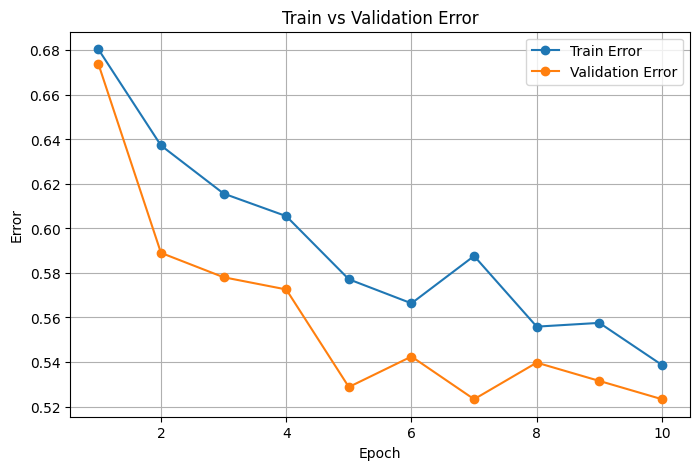

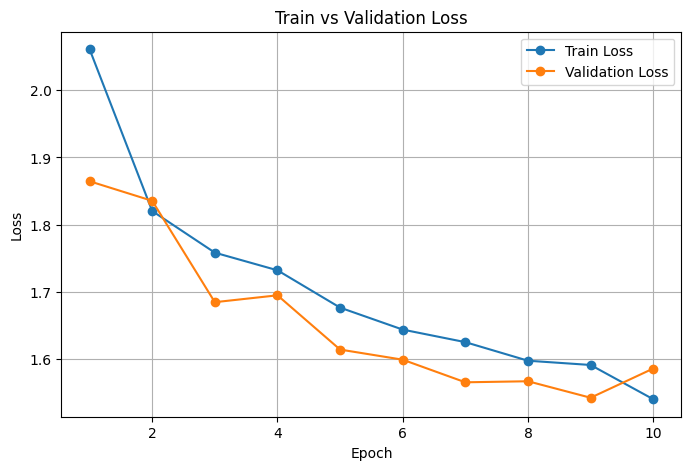

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN3D(num_classes=len(label_map), dropout_prob=0.3)

model, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model, train_loader, val_loader, device, total_epochs=10, lr=1e-3
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)



In [ ]:
#Try CNN3D but batch increased from 8->16

Using device: cuda
Epoch 1/10 | Train Loss: 2.0775 | Train Acc: 0.3462 | Val Loss: 1.6674 | Val Acc: 0.4438
Epoch 2/10 | Train Loss: 1.7140 | Train Acc: 0.4066 | Val Loss: 1.6108 | Val Acc: 0.4384
Epoch 3/10 | Train Loss: 1.6421 | Train Acc: 0.4306 | Val Loss: 1.5884 | Val Acc: 0.4411
Epoch 4/10 | Train Loss: 1.6158 | Train Acc: 0.4455 | Val Loss: 1.5163 | Val Acc: 0.4822
Epoch 5/10 | Train Loss: 1.5564 | Train Acc: 0.4515 | Val Loss: 1.5370 | Val Acc: 0.4658
Epoch 6/10 | Train Loss: 1.5259 | Train Acc: 0.4759 | Val Loss: 1.4967 | Val Acc: 0.5068
Epoch 7/10 | Train Loss: 1.4871 | Train Acc: 0.4779 | Val Loss: 1.4551 | Val Acc: 0.5205
Epoch 8/10 | Train Loss: 1.4752 | Train Acc: 0.4867 | Val Loss: 1.4619 | Val Acc: 0.4877
Epoch 9/10 | Train Loss: 1.4396 | Train Acc: 0.5012 | Val Loss: 1.3932 | Val Acc: 0.5123
Epoch 10/10 | Train Loss: 1.4383 | Train Acc: 0.5086 | Val Loss: 1.4168 | Val Acc: 0.5041
Training complete.


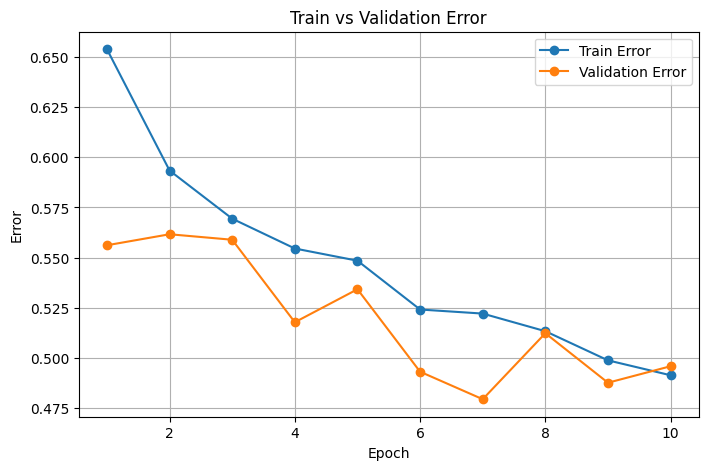

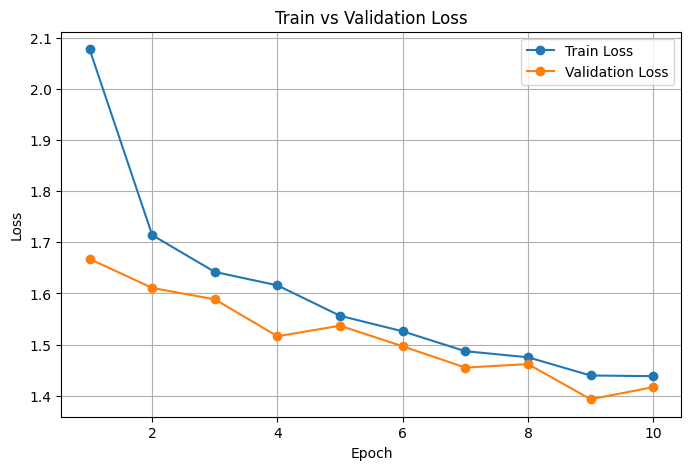

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN3D(num_classes=len(label_map), dropout_prob=0.3)

model, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model, train_loader, val_loader, device, total_epochs=10, lr=1e-3
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)


**10) Try a bigger 3D CNN**


In [26]:
class CNN3D_Improved_v2(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.2):
        super(CNN3D_Improved_v2, self).__init__()

        # Conv Block 1: 1 -> 32
        self.conv1 = nn.Conv3d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm3d(32)

        # Conv Block 2: 32 -> 64
        self.conv2 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm3d(64)

        # Conv Block 3: 64 -> 128
        self.conv3 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm3d(128)

        # Conv Block 4: 128 -> 256
        self.conv4 = nn.Conv3d(128, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm3d(256)

        # 3D Max Pooling
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

        # Fully connected layers
        # After pooling: D,H,W = 16->8->4->2->1 ; 64->32->16->8->4
        self.fc1 = nn.Linear(256*1*4*4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Conv Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        # Conv Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        # Conv Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        # Conv Block 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


Using device: cuda
Epoch 1/10 | Train Loss: 1.8850 | Train Acc: 0.3516 | Val Loss: 1.8166 | Val Acc: 0.3260
Epoch 2/10 | Train Loss: 1.7031 | Train Acc: 0.4262 | Val Loss: 1.5939 | Val Acc: 0.4575
Epoch 3/10 | Train Loss: 1.7034 | Train Acc: 0.4265 | Val Loss: 1.6148 | Val Acc: 0.3918
Epoch 4/10 | Train Loss: 1.6315 | Train Acc: 0.4367 | Val Loss: 1.5919 | Val Acc: 0.4630
Epoch 5/10 | Train Loss: 1.6084 | Train Acc: 0.4461 | Val Loss: 1.8657 | Val Acc: 0.3068
Epoch 6/10 | Train Loss: 1.6149 | Train Acc: 0.4482 | Val Loss: 1.5540 | Val Acc: 0.4630
Epoch 7/10 | Train Loss: 1.5090 | Train Acc: 0.4840 | Val Loss: 1.5782 | Val Acc: 0.4466
Epoch 8/10 | Train Loss: 1.5022 | Train Acc: 0.4840 | Val Loss: 2.1369 | Val Acc: 0.3534
Epoch 9/10 | Train Loss: 1.4917 | Train Acc: 0.4914 | Val Loss: 1.5192 | Val Acc: 0.4877
Epoch 10/10 | Train Loss: 1.4560 | Train Acc: 0.5066 | Val Loss: 1.4908 | Val Acc: 0.4767
Training complete.


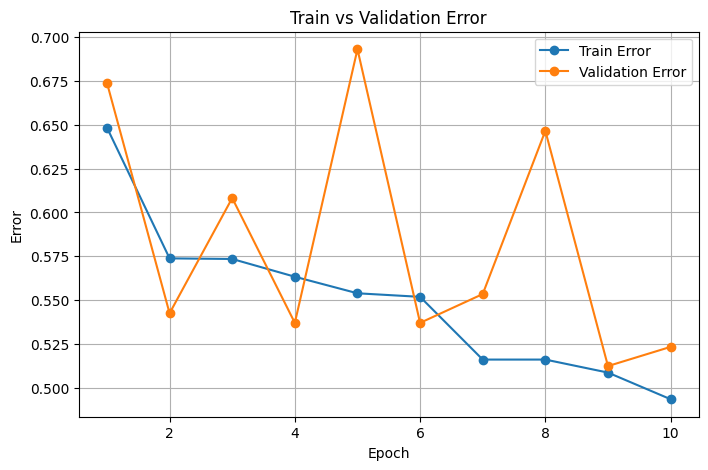

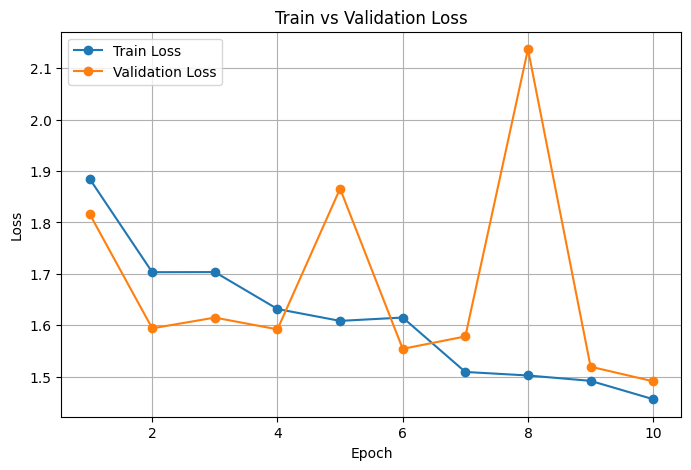

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN3D_Improved_v2(num_classes=len(label_map), dropout_prob=0.3)

model, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model, train_loader, val_loader, device, total_epochs=10, lr=1e-3
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)

Using device: cuda
Epoch 1/10 | Train Loss: 2.1300 | Train Acc: 0.3462 | Val Loss: 1.6857 | Val Acc: 0.3918
Epoch 2/10 | Train Loss: 1.6946 | Train Acc: 0.4066 | Val Loss: 1.6128 | Val Acc: 0.4466
Epoch 3/10 | Train Loss: 1.6156 | Train Acc: 0.4444 | Val Loss: 1.5867 | Val Acc: 0.4384
Epoch 4/10 | Train Loss: 1.5725 | Train Acc: 0.4505 | Val Loss: 1.6751 | Val Acc: 0.3945
Epoch 5/10 | Train Loss: 1.5116 | Train Acc: 0.4765 | Val Loss: 1.5756 | Val Acc: 0.4795
Epoch 6/10 | Train Loss: 1.4824 | Train Acc: 0.4894 | Val Loss: 1.5007 | Val Acc: 0.4575
Epoch 7/10 | Train Loss: 1.4617 | Train Acc: 0.4931 | Val Loss: 1.5354 | Val Acc: 0.4493
Epoch 8/10 | Train Loss: 1.4208 | Train Acc: 0.5042 | Val Loss: 1.4665 | Val Acc: 0.4932
Epoch 9/10 | Train Loss: 1.3687 | Train Acc: 0.5214 | Val Loss: 1.6159 | Val Acc: 0.4548
Epoch 10/10 | Train Loss: 1.3370 | Train Acc: 0.5390 | Val Loss: 1.4660 | Val Acc: 0.4822
Training complete.


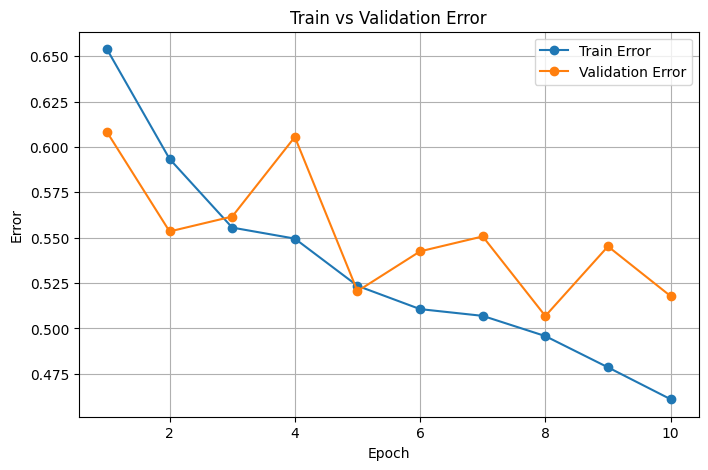

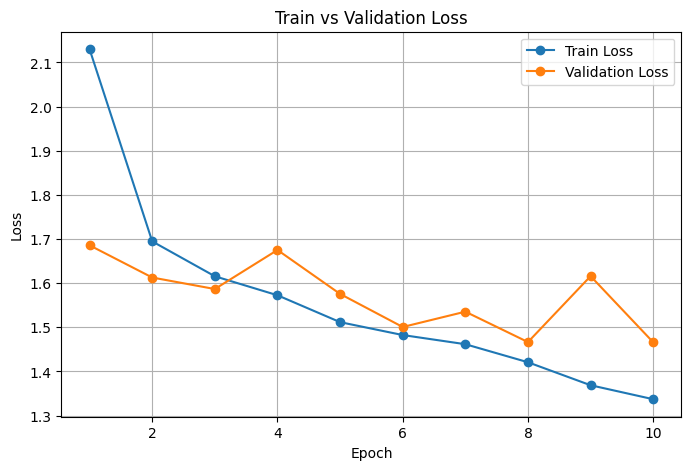

In [30]:
#Try CNN3D but bacth increased from 16->32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN3D(num_classes=len(label_map), dropout_prob=0.3)

model, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model, train_loader, val_loader, device, total_epochs=10, lr=1e-3
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)

Using device: cuda
Epoch 1/20 | Train Loss: 2.0267 | Train Acc: 0.3438 | Val Loss: 1.6201 | Val Acc: 0.4301
Epoch 2/20 | Train Loss: 1.7265 | Train Acc: 0.4090 | Val Loss: 1.5433 | Val Acc: 0.4795
Epoch 3/20 | Train Loss: 1.6758 | Train Acc: 0.4137 | Val Loss: 1.5780 | Val Acc: 0.4356
Epoch 4/20 | Train Loss: 1.6401 | Train Acc: 0.4333 | Val Loss: 1.4942 | Val Acc: 0.4959
Epoch 5/20 | Train Loss: 1.5923 | Train Acc: 0.4509 | Val Loss: 1.5507 | Val Acc: 0.4767
Epoch 6/20 | Train Loss: 1.5606 | Train Acc: 0.4553 | Val Loss: 1.4765 | Val Acc: 0.4986
Epoch 7/20 | Train Loss: 1.5629 | Train Acc: 0.4522 | Val Loss: 1.5109 | Val Acc: 0.4658
Epoch 8/20 | Train Loss: 1.4849 | Train Acc: 0.4796 | Val Loss: 1.5942 | Val Acc: 0.4630
Epoch 9/20 | Train Loss: 1.4448 | Train Acc: 0.4880 | Val Loss: 1.4492 | Val Acc: 0.5205
Epoch 10/20 | Train Loss: 1.4234 | Train Acc: 0.5035 | Val Loss: 1.4116 | Val Acc: 0.5370
Epoch 11/20 | Train Loss: 1.4285 | Train Acc: 0.5086 | Val Loss: 1.3918 | Val Acc: 0.5425


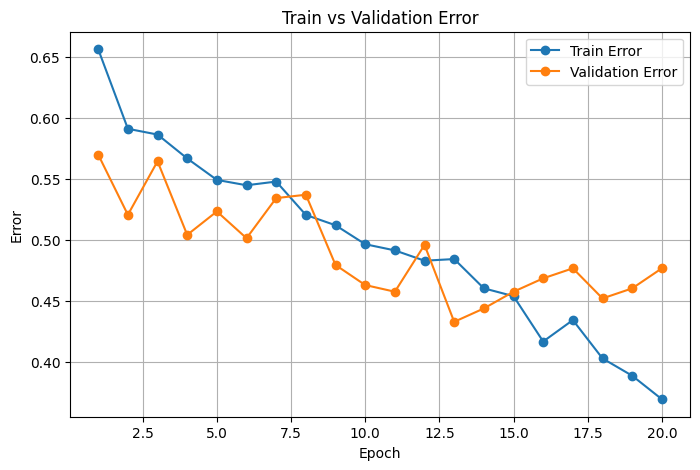

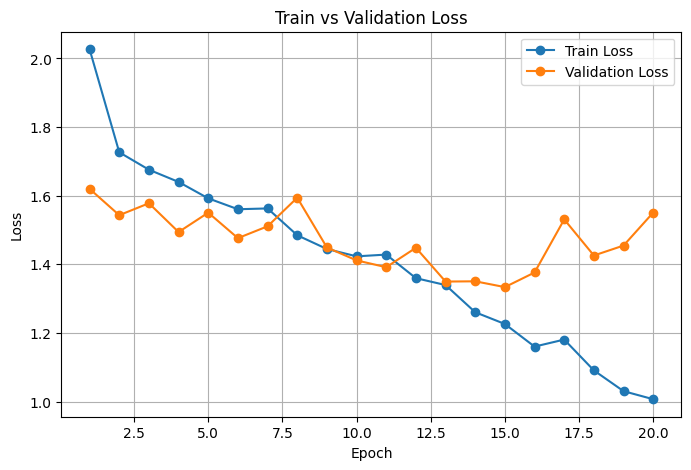

In [33]:
#Go back to 16 batch + increasing epoch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN3D(num_classes=len(label_map), dropout_prob=0.3)

model, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model, train_loader, val_loader, device, total_epochs=20, lr=1e-3
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)